In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv('cloud/train.csv')
data.isnull().sum()

Image_Label          0
EncodedPixels    10348
dtype: int64

In [10]:
image_ids = data['Image_Label'].str.rsplit('_', n=1).str[1]
unique_image_names = image_ids.unique()
unique_image_names

array(['Fish', 'Flower', 'Gravel', 'Sugar'], dtype=object)

In [134]:
# ------------------------------------------------------------
# 1. ПРОСТОЙ DATASET (без negative strides)
# ------------------------------------------------------------
class CloudDataset(Dataset):
    def __init__(self, data, image_dir):
        self.data = data
        self.image_dir = image_dir
        self.ids = data['Image_Label'].apply(lambda x: x.split('_')[0]).unique()
        self.classes = ['Sugar', 'Gravel', 'Flower', 'Fish']

    def __len__(self):
        return len(self.ids)
    
    def rle_decode(self, rle, shape):
        if pd.isna(rle) or rle == '-1':
            return np.zeros(shape, dtype=np.uint8)
        
        s = rle.split()
        starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
        starts -= 1
        ends = starts + lengths

        img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for lo, hi in zip(starts, ends):
            img[lo:hi] = 1

        return img.reshape(shape, order='F')

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # --- IMAGE ---
        img = cv2.imread(os.path.join(self.image_dir, img_id))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- MASK (ВАЖНО!) ---
        mask = np.zeros((1400, 2100, 4), dtype=np.uint8)

        for i, cls in enumerate(self.classes):
            row = self.data[self.data['Image_Label'] == f"{img_id}_{cls}"]
            if not row.empty:
                rle = row['EncodedPixels'].values[0]
                mask[:, :, i] = self.rle_decode(rle, (1400, 2100))

        # --- RESIZE (после decode!) ---
        img = cv2.resize(img, (256, 256))
        mask_resized = np.zeros((256, 256, 4), dtype=np.float32)

        for i in range(4):
            mask_resized[:, :, i] = cv2.resize(
                mask[:, :, i],
                (256, 256),
                interpolation=cv2.INTER_NEAREST  # ВАЖНО!
            )

        # --- TO TENSOR ---
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        # mask = torch.from_numpy(mask_resized).permute(2, 0, 1).float()
        mask_indices = np.argmax(mask_resized, axis=2)  # [256, 256] со значениями 0-3
        mask = torch.from_numpy(mask_indices).long()
        

        return img, mask


class AdvancedSegCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Энкодер (уменьшаем с 256 до 32)
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)     # 3 канала RGB -> 16 признаков
        """
        3 — на входе 3 канала (RGB, цветная фотка).
        16 — на выходе 16 новых картинок (карт признаков). Сеть создаст 16 разных "очков", чтобы смотреть на фото.
        3 — размер окошка 3x3 пикселя.
        padding=1 — добавляет рамку в 1 пиксель по краям, чтобы размер картинки не уменьшался (было 256, осталось 256).
        """
        self.bn1 = nn.BatchNorm2d(16)                   # Нормализуем 16 каналов
        self.lrelu1 = nn.LeakyReLU(0.01, inplace=True)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)    # 16 -> 32 признака
        self.bn2 = nn.BatchNorm2d(32)                   # Нормализуем 32 канал
        self.lrelu2 = nn.LeakyReLU(0.01, inplace=True)  
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)    # 32 -> 64 признака
        self.bn3 = nn.BatchNorm2d(64)                   # Нормализуем 64 канал
        self.lrelu3 = nn.LeakyReLU(0.01, inplace=True)
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)   # 64 -> 128 признаков
        self.bn4 = nn.BatchNorm2d(128)                  # Нормализуем 128
        self.lrelu4 = nn.LeakyReLU(0.01, inplace=True)
        self.pool = nn.MaxPool2d(2, 2)                  # Уменьшает картинку в 2 раза. Было 256x256 → стало 128x128.
        self.dropout = nn.Dropout2d(0.5)                # Во время обучения случайно выключает 50% нейронов
        
        # Декодер (увеличиваем обратно до 256)
        # 32 -> 64 -> 128 -> 256
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)     # 16 -> 32
        """
        Вход: 16x16, 128 каналов.
        Выход: 32x32, 64 канала.
        Как работает: Представьте, что у вас есть пиксель. stride=2 значит: 
        "Раздвинь соседние пиксели, а между ними вставь новые, высчитанные по формуле". 
        Картинка становится больше и плавнее.
        """
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)      # 32 -> 64
        self.up3 = nn.ConvTranspose2d(32, 16, 2, stride=2)      # 64 -> 128
        self.up4 = nn.ConvTranspose2d(16, 16, 2, stride=2)      # 128 -> 256
        
        # Финальный слой
        self.out = nn.Conv2d(16, 4, 1)  # 16 признаков -> 4 маски
        # 16 → 4: Было 16 карт признаков, превращаем в 4 маски (Sugar, Gravel, Flower, Fish).

    def forward(self, x):
        # Encoder
        x1 = self.pool(self.lrelu1(self.bn1(self.conv1(x))))   # 256 → 128
        x2 = self.pool(self.lrelu2(self.bn2(self.conv2(x1))))  # 128 → 64
        x3 = self.pool(self.lrelu3(self.bn3(self.conv3(x2))))  # 64 → 32
        x4 = self.pool(self.lrelu4(self.bn4(self.conv4(x3))))  # 32 → 16

        x4 = self.dropout(x4)

        # # Decoder
        # x = F.relu(self.up1(x4))  # 16 → 32
        # x = F.relu(self.up2(x))   # 32 → 64
        # x = F.relu(self.up3(x))   # 64 → 128
        # x = F.relu(self.up4(x))   # 128 → 256
        # Decoder
        x = F.leaky_relu(self.up1(x4))  # 16 → 32
        x = F.leaky_relu(self.up2(x))   # 32 → 64
        x = F.leaky_relu(self.up3(x))   # 64 → 128
        x = F.leaky_relu(self.up4(x))   # 128 → 256

        return self.out(x)
        
        # Выход
        """
        sigmoid: Сжимает любое число в диапазон [0, 1]. Получаем вероятность того, что в этом пикселе есть облако.
        Если > 0.5 — считаем что облако есть (1). Если < 0.5 — нет (0).
        """
        # return self.out(x)



In [135]:
# ------------------------------------------------------------
# 3. ЗАГРУЗКА И ПРОВЕРКА
# ------------------------------------------------------------
image_dir = 'cloud/train_images'

# Создаём ОДИН датасет из train
full_dataset = CloudDataset(data, image_dir)

# Разделяем на train/val
from sklearn.model_selection import train_test_split

all_ids = data['Image_Label'].apply(lambda x: x.split('_')[0]).unique()
train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=42)

train_data = data[data['Image_Label'].apply(lambda x: x.split('_')[0]).isin(train_ids)]
val_data = data[data['Image_Label'].apply(lambda x: x.split('_')[0]).isin(val_ids)]

train_dataset = CloudDataset(train_data, image_dir)
val_dataset = CloudDataset(val_data, image_dir)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images")

Train: 4436 images, Val: 1110 images


In [136]:
# ------------------------------------------------------------
# 5. ФУНКЦИЯ ПОТЕРЬ И МЕТРИКА DICE
# ------------------------------------------------------------
def dice_score(pred, target, smooth=1e-6):
    """
    pred: [batch, 4, 256, 256] — логиты от модели
    target: [batch, 256, 256] — индексы классов (0-3)
    """
    # Превращаем логиты в индексы классов
    pred_classes = torch.argmax(pred, dim=1)  # [batch, 256, 256]
    
    # Превращаем индексы в one-hot для подсчёта Dice
    pred_one_hot = F.one_hot(pred_classes, num_classes=4).permute(0, 3, 1, 2).float()
    target_one_hot = F.one_hot(target, num_classes=4).permute(0, 3, 1, 2).float()
    
    intersection = (pred_one_hot * target_one_hot).sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (pred_one_hot.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3)) + smooth)
    return dice.mean().item()

def dice_loss(pred, target, smooth=1e-6):
#     pred = torch.sigmoid(pred)#pred.contiguous()
#     pred = (pred > 0.5).float()# target = target.contiguous()
    
#     intersection = (pred * target).sum(dim=(2,3))
#     union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    
#     dice = (2. * intersection + smooth) / (union + smooth)
    
#     return 1 - dice.mean()
    pred_soft = F.softmax(pred, dim=1)  # ← Softmax для 4 классов
    target_one_hot = F.one_hot(target, num_classes=4).permute(0, 3, 1, 2).float()
    
    intersection = (pred_soft * target_one_hot).sum(dim=(2, 3))
    union = pred_soft.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()  # ← Градиент течёт через pred_soft!

In [83]:
def calculate_weights(dataset):
    total_pixels = 0
    class_pixels = [0, 0, 0, 0]
    
    for idx in range(len(dataset)):
        _, mask = dataset[idx]
        total_pixels += 256 * 256
        for i in range(4):
            class_pixels[i] += mask[i].sum().item()
    
    weights = []
    for pixels in class_pixels:
        neg = total_pixels - pixels
        w = neg / (pixels + 1)  # +1 чтобы не делить на ноль
        weights.append(min(w, 15.0))
    
    return torch.tensor(weights)

pos_weights = calculate_weights(train_dataset).to(device)

In [137]:
device = torch.device('mps')
print(f"Device: {device}")
pos_weights = pos_weights.view(1, 4, 1, 1)
model = AdvancedSegCNN().to(device)
# model = ResNet18().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# bce_loss = nn.BCELoss()
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
criterion = nn.CrossEntropyLoss()

# Для графиков
history = {'train_loss': [], 'val_dice': []}

# Early stopping
best_dice = 0
patience = 7
counter = 0

epochs = 30

for epoch in range(epochs):
    # Тренировка
    model.train()
    train_loss = 0.0
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        # print("outputs:", outputs.shape)
        # print("masks:", masks.shape)
        # if masks.shape[1] != 4:
        #     masks = masks.permute(0, 3, 1, 2)
        # Комбинированный лосс
        loss = criterion(outputs, masks) + 0.1 * dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)
    
    # Валидация
    model.eval()
    val_dice_sum = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_dice_sum += dice_score(outputs, masks)
    
    val_dice = val_dice_sum / len(val_loader)
    history['val_dice'].append(val_dice)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f}")
    
    # Early stopping
    if val_dice > best_dice or train_loss < min(history['train_loss']):
        best_dice = val_dice
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
        print(f"  ✅ Saved! Best Dice: {best_dice:.4f}")
    # else:
    #     counter += 1
    #     if counter >= patience:
    #         print(f"  🛑 Early stopping at epoch {epoch+1}")
    #         break

print(f"\nОбучение завершено. Лучший Dice: {best_dice:.4f}")

Device: mps
Epoch  1/30 | Loss: 1.1722 | Val Dice: 0.5799
  ✅ Saved! Best Dice: 0.5799
Epoch  2/30 | Loss: 1.0076 | Val Dice: 0.5799
Epoch  3/30 | Loss: 1.0017 | Val Dice: 0.5799
Epoch  4/30 | Loss: 0.9972 | Val Dice: 0.5799
Epoch  5/30 | Loss: 0.9953 | Val Dice: 0.5799
Epoch  6/30 | Loss: 0.9905 | Val Dice: 0.5799
Epoch  7/30 | Loss: 0.9911 | Val Dice: 0.5799
Epoch  8/30 | Loss: 0.9882 | Val Dice: 0.5799
Epoch  9/30 | Loss: 0.9868 | Val Dice: 0.5799
Epoch 10/30 | Loss: 0.9867 | Val Dice: 0.5799
Epoch 11/30 | Loss: 0.9836 | Val Dice: 0.5799
Epoch 12/30 | Loss: 0.9826 | Val Dice: 0.5799
Epoch 13/30 | Loss: 0.9804 | Val Dice: 0.5799
Epoch 14/30 | Loss: 0.9786 | Val Dice: 0.5718
Epoch 15/30 | Loss: 0.9731 | Val Dice: 0.4695
Epoch 16/30 | Loss: 0.9615 | Val Dice: 0.4890
Epoch 17/30 | Loss: 0.9447 | Val Dice: 0.5009
Epoch 18/30 | Loss: 0.9356 | Val Dice: 0.5012
Epoch 19/30 | Loss: 0.9285 | Val Dice: 0.5078
Epoch 20/30 | Loss: 0.9234 | Val Dice: 0.5058
Epoch 21/30 | Loss: 0.9195 | Val Dice: 

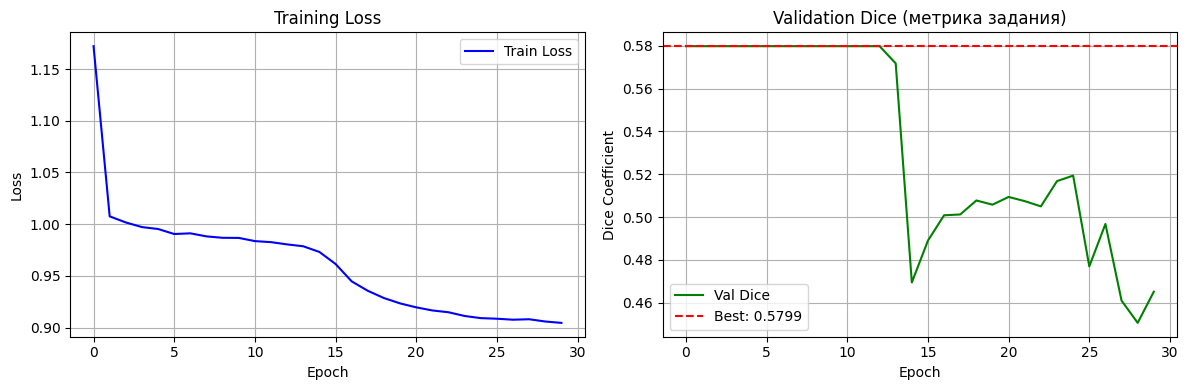

In [138]:
# ------------------------------------------------------------
# 7. ГРАФИК ОБУЧЕНИЯ 
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], 'b-', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['val_dice'], 'g-', label='Val Dice')
ax2.axhline(y=best_dice, color='r', linestyle='--', label=f'Best: {best_dice:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Coefficient')
ax2.set_title('Validation Dice (метрика задания)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [38]:
# ------------------------------------------------------------
# 8. ФИНАЛЬНАЯ ОЦЕНКА (загружаем лучшую модель)
# ------------------------------------------------------------
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

final_dice = 0.0
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        final_dice += dice_score(outputs, masks)

print(f"Финальный Dice на валидации: {final_dice / len(val_loader):.4f}")

Финальный Dice на валидации: 0.2832


In [139]:
import matplotlib.pyplot as plt
import numpy as np

def predict_and_show(model, dataset, idx, device='mps'):
    """
    Показывает оригинальную картинку, истинную маску и предсказание модели
    
    model: обученная модель
    dataset: датасет (train или val)
    idx: индекс картинки в датасете
    """
    model.eval()
    
    # Берём картинку и маску из датасета
    image, true_mask = dataset[idx]
    
    # Добавляем размерность batch (1, C, H, W)
    image_batch = image.unsqueeze(0).to(device)
    
    # Предсказание
    with torch.no_grad():
        pred_mask = model(image_batch)
        pred_mask = pred_mask.cpu().squeeze(0)  # Убираем batch размерность
        pred_classes = torch.argmax(pred_mask, dim=0)
    
    # Классы облаков
    classes = ['Sugar', 'Gravel', 'Flower', 'Fish']
    
    # Рисуем
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # 1. Оригинальная картинка
    img_show = image.permute(1, 2, 0).numpy()
    # Денормализация если была нормализация
    img_show = np.clip(img_show, 0, 1)
    axes[0, 0].imshow(img_show)
    axes[0, 0].set_title('Оригинал')
    axes[0, 0].axis('off')
    
    # 2. Комбинированная истинная маска (все классы разными цветами)
    true_combined = np.zeros((256, 256, 3))
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]  # Красный, Зеленый, Синий, Желтый
    
    for i in range(4):
        mask_channel = (true_mask.numpy() == i)
        for c in range(3):
            true_combined[:, :, c] += mask_channel * colors[i][c] / 255.0
    
    axes[0, 1].imshow(np.clip(true_combined, 0, 1))
    axes[0, 1].set_title('Истинная маска')
    axes[0, 1].axis('off')
    
    # 3. Комбинированная предсказанная маска
    pred_combined = np.zeros((256, 256, 3))
    for i in range(4):
        mask_channel = (pred_classes.numpy() == i)
        for c in range(3):
            pred_combined[:, :, c] += mask_channel * colors[i][c] / 255.0
    
    axes[0, 2].imshow(np.clip(pred_combined, 0, 1))
    axes[0, 2].set_title('Предсказание')
    axes[0, 2].axis('off')
    
    # 4. Пустые ячейки
    axes[0, 3].axis('off')
    axes[0, 4].axis('off')
    
    # 5. Отдельные классы (истина vs предсказание)
    for i, class_name in enumerate(classes):
        # Истина
        axes[1, i].imshow((true_mask.numpy() == i), cmap='gray')
        axes[1, i].set_title(f'{class_name} (True)')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Считаем Dice для каждого класса
    print("Dice Score по классам:")
    for i, class_name in enumerate(classes):
        pred = (pred_classes.numpy() == i).astype(np.float32).flatten()
        true = (true_mask.numpy() == i).astype(np.float32).flatten()
        intersection = (pred * true).sum()
        dice = 2 * intersection / (pred.sum() + true.sum() + 1e-6)
        print(f"  {class_name}: {dice:.4f}")

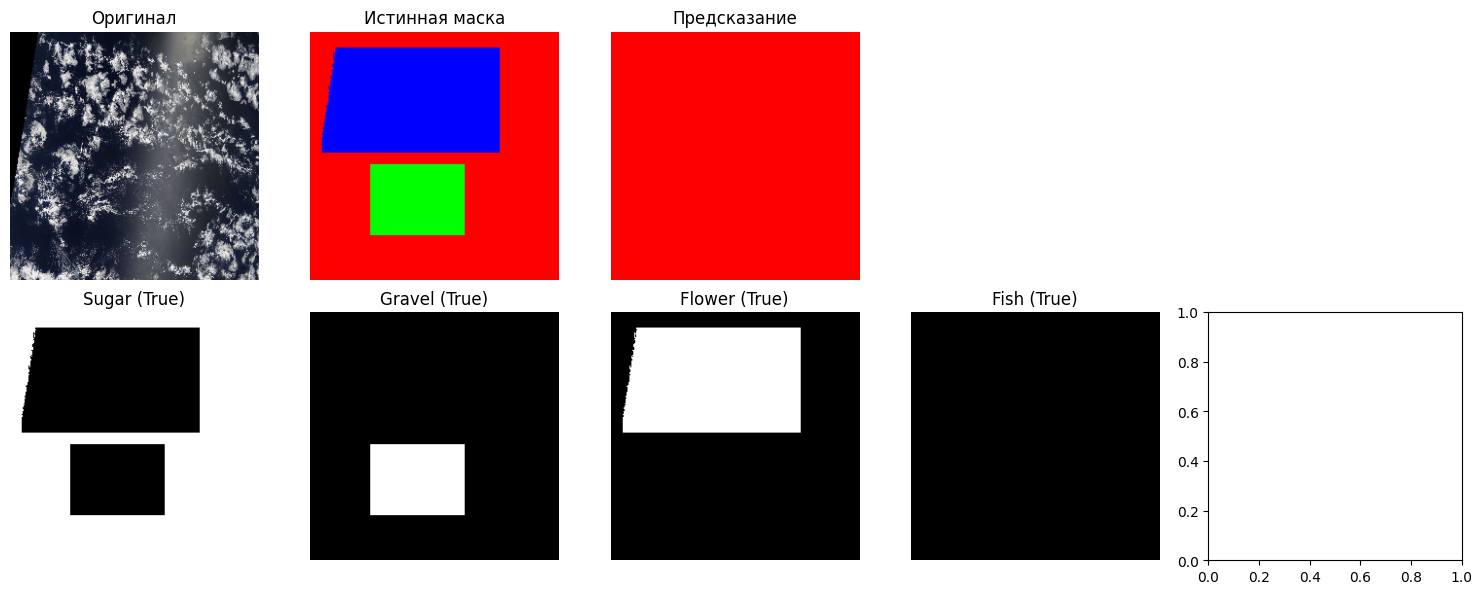

Dice Score по классам:
  Sugar: 0.7507
  Gravel: 0.0000
  Flower: 0.0000
  Fish: 0.0000


In [144]:
# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)

# Показываем случайный пример из валидации
import random
idx = random.randint(0, len(val_dataset) - 1)
predict_and_show(model, val_dataset, idx, device)